# Benchmarking spot counting using Vision Language Models

Now, we want to apply [moondream](https://huggingface.co/vikhyatk/moondream2) on different and potentially more challenging biological examples to see how it performs.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image, ImageDraw
from image_utilities import numpy_to_bytestream, extract_json, generate_spots
from tqdm import tqdm
import stackview
from skimage import data
import numpy as np
from skimage import img_as_ubyte

In [2]:

model = AutoModelForCausalLM.from_pretrained(
    "vikhyatk/moondream2",
    revision="2025-01-09",
    trust_remote_code=True,
    # Comment to run on CPU. To use the GPU, you need about 5 GB of GPU Memory.
    # GPU "cuda"
    # On Apple Silicon, use "mps"
    device_map={"": "mps"}
)

## Cell nuclei


StackViewNDArray([[ 8868,  6923,  5690, ..., 13942, 12804, 14653],
                  [ 7113,  5501,  5216, ..., 16739, 13657, 15554],
                  [ 5833,  7160,  5928, ..., 15838, 16739, 17166],
                  ...,
                  [ 2513,  3936,  3414, ...,  3699,  4126,  4220],
                  [ 3319,  3272,  2513, ...,  3699,  3367,  2940],
                  [ 3130,  3794,  3225, ...,  2987,  3746,  4315]],
                 shape=(256, 256), dtype=uint16)
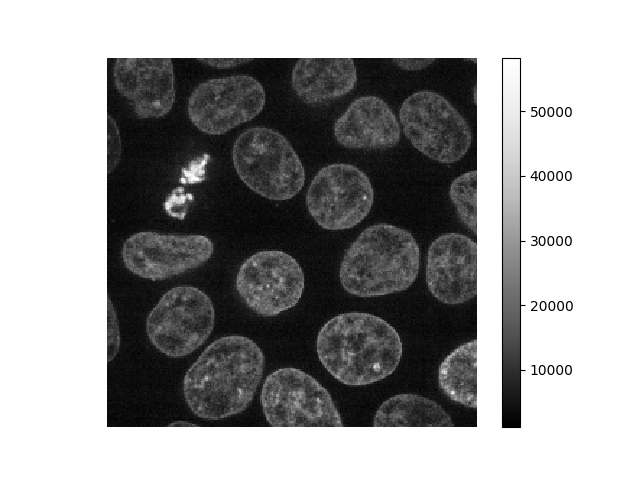
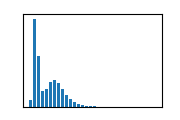

In [3]:
# Load the human mitosis dataset
nuclei = data.cells3d()[30, 1, :, :]

# Display the image
stackview.insight(nuclei)

In [4]:
nuclei_uint8 = img_as_ubyte(nuclei)
pil_nuclei = Image.fromarray(nuclei_uint8)

In [5]:
encoded_nuclei = model.encode_image(pil_nuclei)

In [6]:
# Pointing
print("\nPointing: 'bright spot'")
points_nuclei = model.point(encoded_nuclei, "Mark the bright dots")["points"]
print(f"Found {len(points_nuclei)} bright spot(s)")


Pointing: 'bright spot'
Found 50 bright spot(s)


In [7]:
box_half_size_nuclei = 5 / nuclei_uint8.shape[0]
bb_nuclei = [{'x':p['x']-box_half_size_nuclei, 'y':p['y']-box_half_size_nuclei, 'width':2*box_half_size_nuclei, 'height':2*box_half_size_nuclei } for p in points_nuclei]

StackViewNDArray([[[34, 34, 34],
                   [26, 26, 26],
                   [20, 20, 20],
                   ...,
                   [57, 57, 57],
                   [52, 52, 52],
                   [60, 60, 60]],

                  [[26, 26, 26],
                   [19, 19, 19],
                   [18, 18, 18],
                   ...,
                   [69, 69, 69],
                   [56, 56, 56],
                   [64, 64, 64]],

                  [[20, 20, 20],
                   [26, 26, 26],
                   [21, 21, 21],
                   ...,
                   [65, 65, 65],
                   [69, 69, 69],
                   [72, 72, 72]],

                  ...,

                  [[ 5,  5,  5],
                   [12, 12, 12],
                   [10, 10, 10],
                   ...,
                   [11, 11, 11],
                   [13, 13, 13],
                   [13, 13, 13]],

                  [[ 9,  9,  9],
                   [ 9,  9,  9],
                   [ 5,  5,  5],
                   ...,
                   [11, 11, 11],
                   [10, 10, 10],
                   [ 8,  8,  8]],

                  [[ 9,  9,  9],
                   [11, 11, 11],
                   [ 9,  9,  9],
                   ...,
                   [ 8,  8,  8],
                   [11, 11, 11],
                   [13, 13, 13]]], shape=(256, 256, 3), dtype=uint8)
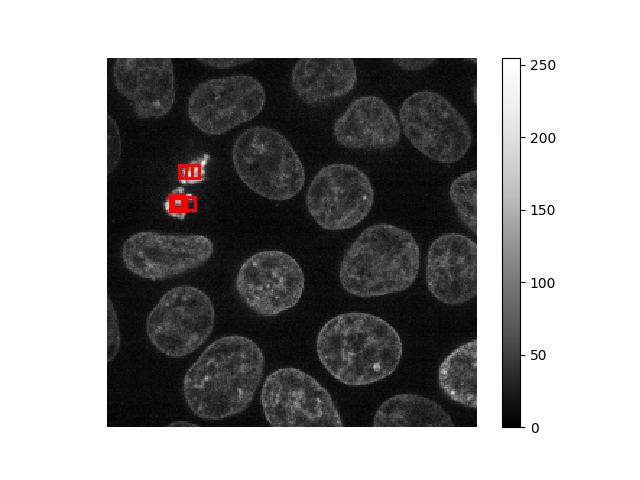
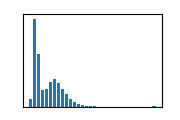

In [8]:
stackview.add_bounding_boxes(nuclei_uint8, bb_nuclei)

Uneven illumination or intensity bias can lead spot detectors (especially prompt-based or ML-based ones like Moondream) to focus only on the brightest region, ignoring fainter but still valid spots.

## Cropped image

Let us try to crop out the bright region:

StackViewNDArray([[12566, 11523,  8868, ..., 13942, 12804, 14653],
                  [12898,  8251,  5833, ..., 16739, 13657, 15554],
                  [ 5880,  5311,  5975, ..., 15838, 16739, 17166],
                  ...,
                  [ 3699,  3177,  3604, ...,  3699,  4126,  4220],
                  [ 2608,  4126,  4647, ...,  3699,  3367,  2940],
                  [ 4505,  4363,  4552, ...,  2987,  3746,  4315]],
                 shape=(256, 156), dtype=uint16)
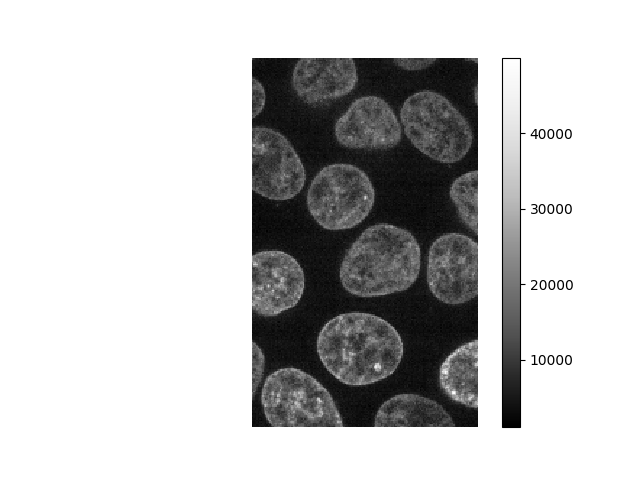
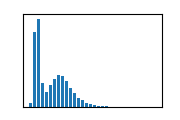

In [9]:
# Example: crop out the central 100x100 region
nuclei_cropped = nuclei[:,100:300]
stackview.insight(nuclei_cropped)

In [10]:
nuclei_cropped_uint8 = img_as_ubyte(nuclei_cropped)
pil_nuclei_cropped = Image.fromarray(nuclei_cropped_uint8)

In [11]:
encoded_nuclei_cropped = model.encode_image(pil_nuclei_cropped)

In [12]:
# Pointing
print("\nPointing: 'bright spot'")
points_nuclei_cropped = model.point(encoded_nuclei_cropped, "Mark the bright dots")["points"]
print(f"Found {len(points_nuclei_cropped)} bright spot(s)")


Pointing: 'bright spot'
Found 50 bright spot(s)


In [13]:
box_half_size_nuclei_cropped = 5 / nuclei_cropped.shape[0]
bb_nuclei_cropped = [{'x':p['x']-box_half_size_nuclei_cropped, 'y':p['y']-box_half_size_nuclei_cropped, 'width':2*box_half_size_nuclei_cropped, 'height':2*box_half_size_nuclei_cropped} for p in points_nuclei_cropped]

StackViewNDArray([[[59, 59, 59],
                   [54, 54, 54],
                   [40, 40, 40],
                   ...,
                   [67, 67, 67],
                   [61, 61, 61],
                   [70, 70, 70]],

                  [[61, 61, 61],
                   [37, 37, 37],
                   [24, 24, 24],
                   ...,
                   [81, 81, 81],
                   [65, 65, 65],
                   [75, 75, 75]],

                  [[24, 24, 24],
                   [22, 22, 22],
                   [25, 25, 25],
                   ...,
                   [76, 76, 76],
                   [81, 81, 81],
                   [83, 83, 83]],

                  ...,

                  [[13, 13, 13],
                   [10, 10, 10],
                   [13, 13, 13],
                   ...,
                   [13, 13, 13],
                   [15, 15, 15],
                   [16, 16, 16]],

                  [[ 7,  7,  7],
                   [15, 15, 15],
                   [18, 18, 18],
                   ...,
                   [13, 13, 13],
                   [11, 11, 11],
                   [ 9,  9,  9]],

                  [[17, 17, 17],
                   [17, 17, 17],
                   [18, 18, 18],
                   ...,
                   [ 9,  9,  9],
                   [13, 13, 13],
                   [16, 16, 16]]], shape=(256, 156, 3), dtype=uint8)
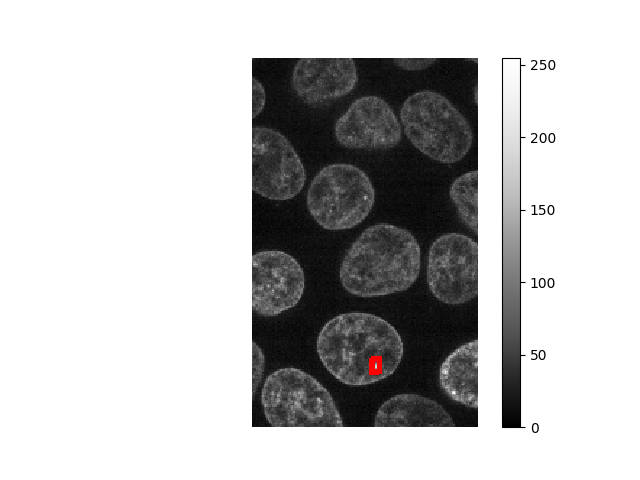
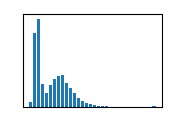

In [14]:
stackview.add_bounding_boxes(nuclei_cropped, bb_nuclei_cropped)

## High-content fluorescence microscopy dataset 

Malou Arvidsson, Salma Kazemi Rashed, & Sonja Aits. (2022). An annotated high-content fluorescence microscopy dataset with Hoechst 33342-stained nuclei and manually labelled outlines (Version 1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.6657260.

StackViewNDArray([[ 5,  8,  6, ...,  1,  1,  2],
                  [ 7, 10,  4, ...,  0,  1,  1],
                  [ 9,  6,  7, ...,  0,  0,  2],
                  ...,
                  [ 8,  6,  8, ..., 19, 23, 18],
                  [12,  8,  8, ..., 24, 21, 21],
                  [ 8,  7,  7, ..., 21, 19, 19]],
                 shape=(1104, 1104), dtype=uint8)
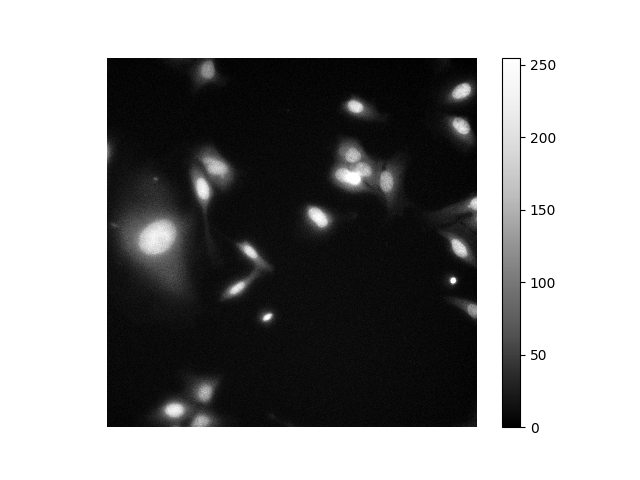
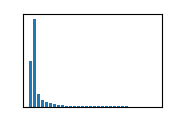

In [ ]:
pil_cells = Image.open("MFGTMPcx7_170702000001_F11f10d0.png").convert("L")  # "L" = grayscale

# Convert to NumPy array
cells = np.array(pil_cells)
stackview.insight(cells)

In [16]:
encoded_cells = model.encode_image(pil_cells)

In [17]:
# Pointing
print("\nPointing: 'bright spot'")
points_cells = model.point(encoded_cells, "Mark the bright dots")["points"]
print(f"Found {len(points_cells)} bright spot(s)")


Pointing: 'bright spot'
Found 19 bright spot(s)


In [18]:
box_half_size_cells = 5 / cells.shape[0]
bb_cells = [{'x':p['x']-box_half_size_cells, 'y':p['y']-box_half_size_cells, 'width':2*box_half_size_cells, 'height':2*box_half_size_cells } for p in points_cells]

StackViewNDArray([[[ 5,  5,  5],
                   [ 8,  8,  8],
                   [ 6,  6,  6],
                   ...,
                   [ 1,  1,  1],
                   [ 1,  1,  1],
                   [ 2,  2,  2]],

                  [[ 7,  7,  7],
                   [10, 10, 10],
                   [ 4,  4,  4],
                   ...,
                   [ 0,  0,  0],
                   [ 1,  1,  1],
                   [ 1,  1,  1]],

                  [[ 9,  9,  9],
                   [ 6,  6,  6],
                   [ 7,  7,  7],
                   ...,
                   [ 0,  0,  0],
                   [ 0,  0,  0],
                   [ 2,  2,  2]],

                  ...,

                  [[ 8,  8,  8],
                   [ 6,  6,  6],
                   [ 8,  8,  8],
                   ...,
                   [19, 19, 19],
                   [23, 23, 23],
                   [18, 18, 18]],

                  [[12, 12, 12],
                   [ 8,  8,  8],
                   [ 8,  8,  8],
                   ...,
                   [24, 24, 24],
                   [21, 21, 21],
                   [21, 21, 21]],

                  [[ 8,  8,  8],
                   [ 7,  7,  7],
                   [ 7,  7,  7],
                   ...,
                   [21, 21, 21],
                   [19, 19, 19],
                   [19, 19, 19]]], shape=(1104, 1104, 3), dtype=uint8)
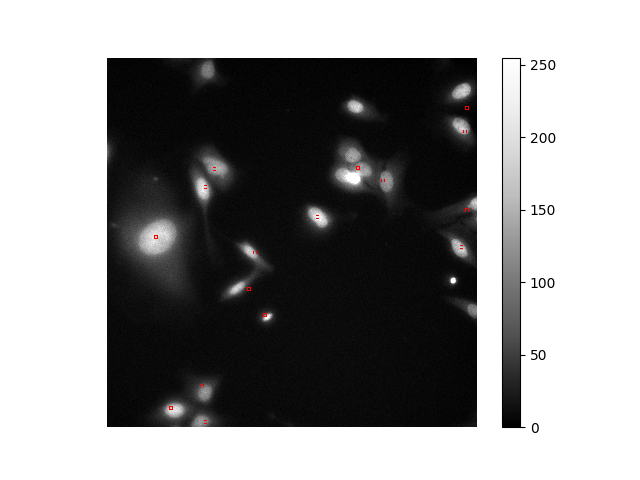
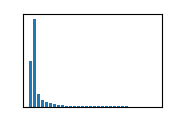

In [19]:
stackview.add_bounding_boxes(cells, bb_cells)